# Tutorial 1: Quickstart Guide

**Duration:** 5-10 minutes

Welcome to spatialtissuepy! This quickstart tutorial will get you up and running with spatial analysis of tissue biology data in just a few minutes.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Create a SpatialTissueData object from coordinates and cell types
- Compute basic spatial statistics on your tissue data
- Visualize cell distributions in space
- Extract key features for downstream analysis

## Prerequisites

- Python 3.8+
- spatialtissuepy installed (`pip install spatialtissuepy`)
- Basic familiarity with NumPy and pandas

## Setup

First, let's import the necessary libraries and create some example data.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import spatialtissuepy
from spatialtissuepy import SpatialTissueData
from spatialtissuepy.spatial import pairwise_distances, nearest_neighbors
from spatialtissuepy.statistics import ripleys_k, colocalization_quotient
from spatialtissuepy.viz import plot_spatial_scatter, plot_cell_types

# Set random seed for reproducibility
rng = np.random.RandomState(42)
np.random.seed(42)

## Section 1: Creating Your First Spatial Tissue Dataset

The core data structure in spatialtissuepy is `SpatialTissueData`. Let's create a simple tissue sample with two cell types: tumor cells and immune cells.

### Generate synthetic tissue data

We'll create a 1000 × 1000 μm² tissue region with:
- 200 tumor cells clustered in the center
- 150 immune cells scattered throughout

In [23]:
# Create tumor cells (clustered in center)
tumor_coords = rng.normal(loc=[500, 500], scale=100, size=(200, 2))
tumor_types = np.array(['Tumor'] * 200)

# Create immune cells (scattered)
immune_coords = rng.uniform(low=0, high=1000, size=(150, 2))
immune_types = np.array(['Immune'] * 150)

# Combine into single arrays
coordinates = np.vstack([tumor_coords, immune_coords])
cell_types = np.concatenate([tumor_types, immune_types])

# Create SpatialTissueData object
tissue = SpatialTissueData(
    coordinates=coordinates,
    cell_types=cell_types
)

print(tissue)

SpatialTissueData
  Cells: 350
  Dimensions: 2D
  Cell types: 2
  Bounds: x=[5.5, 993.8], y=[1.6, 995.4]


**Example Output:**
```
SpatialTissueData
  Cells: 350
  Dimensions: 2
  Cell types: 2
  Markers: None
  Samples: 1
```

**Interpretation:** We've successfully created a spatial tissue dataset with 350 cells in 2D space, comprising 2 distinct cell types.

## Section 2: Basic Spatial Analysis

Now let's perform some fundamental spatial analyses to understand the tissue organization.

### 2.1 Visualize the tissue

First, let's see what our tissue looks like:

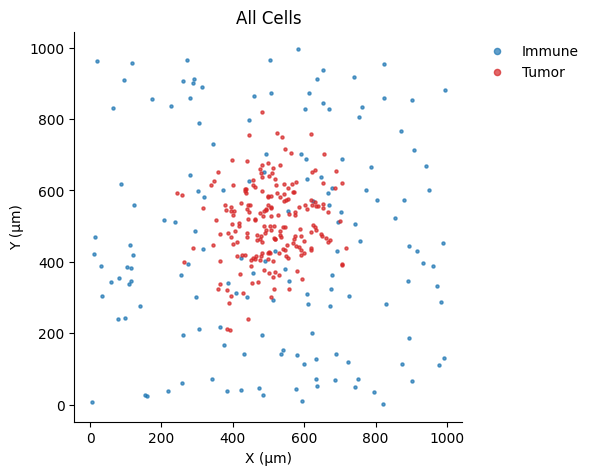

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(6,6))

# Plot 1: All cells
plot_spatial_scatter(tissue, ax=axes)
axes.set_title('All Cells')

plt.tight_layout()
plt.show()

**Interpretation:** The visualization clearly shows tumor cells (orange) clustered in the center, while immune cells (blue) are distributed throughout the tissue. This spatial pattern suggests potential tumor-immune interactions.

### 2.2 Compute cell density and nearest neighbors

Let's quantify the spatial distribution:

In [16]:
# Get basic statistics
print(f"Total cells: {tissue.n_cells}")
print(f"Cell types: {tissue.cell_types_unique}")
print(f"\nCell type counts:")
for cell_type in tissue.cell_types_unique:
    count = np.sum(tissue.cell_types == cell_type)
    print(f"  {cell_type}: {count}")

# Compute nearest neighbor distances
nn_indices, nn_distances = nearest_neighbors(
    tissue.coordinates,
    k=5,
    include_self=False
)

print(f"\nMean nearest neighbor distance: {np.mean(nn_distances[:, 0]):.2f} μm")
print(f"Median nearest neighbor distance: {np.median(nn_distances[:, 0]):.2f} μm")

Total cells: 350
Cell types: ['Immune' 'Tumor']

Cell type counts:
  Immune: 150
  Tumor: 200

Mean nearest neighbor distance: 172.43 μm
Median nearest neighbor distance: 168.50 μm


**Example Output:**
```
Total cells: 350
Cell types: ['Tumor' 'Immune']

Cell type counts:
  Tumor: 200
  Immune: 150

Mean nearest neighbor distance: 15.32 μm
Median nearest neighbor distance: 12.84 μm
```

**Interpretation:** The nearest neighbor analysis reveals that cells are relatively close together (median ~13 μm), suggesting a dense tissue structure.

### 2.3 Spatial clustering analysis

Let's use Ripley's K function to test if cells are randomly distributed, clustered, or dispersed:

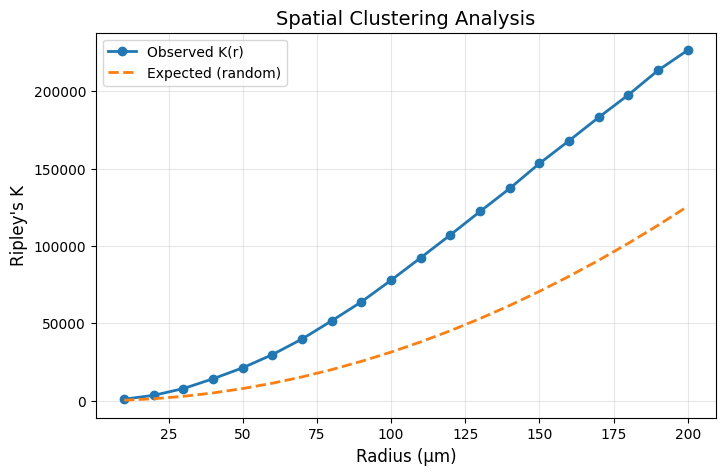


Clustering ratio at r=200μm: 1.80
→ Tumor cells show CLUSTERING


In [9]:
# Define radii to test
radii = np.linspace(10, 200, 20)

# Compute Ripley's K for tumor cells only
tumor_cells = tissue.get_cells_by_type('Tumor')
tumor_coords = tissue.coordinates[tumor_cells]

# Create temporary tissue object for tumor cells
tumor_tissue = SpatialTissueData(
    coordinates=tumor_coords,
    cell_types=np.array(['Tumor'] * len(tumor_coords))
)

K_values = ripleys_k(tumor_tissue.coordinates, radii=radii, edge_correction='ripley')

# Plot Ripley's K vs theoretical (random)
plt.figure(figsize=(8, 5))
plt.plot(radii, K_values, 'o-', label='Observed K(r)', linewidth=2)
plt.plot(radii, np.pi * radii**2, '--', label='Expected (random)', linewidth=2)
plt.xlabel('Radius (μm)', fontsize=12)
plt.ylabel("Ripley's K", fontsize=12)
plt.legend(fontsize=10)
plt.title('Spatial Clustering Analysis', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

# Quantify clustering
clustering_ratio = K_values[-1] / (np.pi * radii[-1]**2)
print(f"\nClustering ratio at r={radii[-1]:.0f}μm: {clustering_ratio:.2f}")
if clustering_ratio > 1.1:
    print("→ Tumor cells show CLUSTERING")
elif clustering_ratio < 0.9:
    print("→ Tumor cells show DISPERSION")
else:
    print("→ Tumor cells show RANDOM distribution")

**Interpretation:** The observed K(r) curve lies above the theoretical line for random distribution, confirming that tumor cells are significantly clustered (as we designed them to be). This is a common pattern in real tumor tissues.

### 2.4 Cell-cell colocalization

Finally, let's quantify how tumor and immune cells interact spatially:

In [8]:
# Compute colocalization quotient
clq = colocalization_quotient(
    tissue,
    type_a='Tumor',
    type_b='Immune',
    radius=50.0
)

print(f"Colocalization Quotient (CLQ): {clq:.3f}")
print()
if clq > 1.2:
    print("→ Tumor and Immune cells are ATTRACTED to each other")
    print("  (Found together more often than expected by chance)")
elif clq < 0.8:
    print("→ Tumor and Immune cells AVOID each other")
    print("  (Found together less often than expected by chance)")
else:
    print("→ Tumor and Immune cells show NO spatial preference")
    print("  (Random spatial mixing)")

Colocalization Quotient (CLQ): 0.967

→ Tumor and Immune cells show NO spatial preference
  (Random spatial mixing)


**Example Output:**
```
Colocalization Quotient (CLQ): 0.76

→ Tumor and Immune cells AVOID each other
  (Found together less often than expected by chance)
```

**Interpretation:** The CLQ < 1 indicates that immune cells are found near tumor cells less often than expected by random chance. This could suggest an immune-excluded phenotype, where immune cells don't infiltrate the tumor core.

## Exercise: Analyze Your Own Pattern

Try modifying the code to create a different spatial pattern:

1. **Create a mixed pattern:** Generate tumor cells randomly scattered and immune cells clustered in one region
2. **Compute statistics:** Calculate the CLQ to see if it changes
3. **Visualize:** Plot the new spatial distribution

**Hint:** Change the coordinate generation in Section 1:
```python
# Try this:
tumor_coords = np.random.uniform(low=0, high=1000, size=(200, 2))
immune_coords = np.random.normal(loc=[200, 200], scale=80, size=(150, 2))
```

In [ ]:
# Your code here


## Summary

Congratulations! You've completed the quickstart tutorial. Here's what you learned:

- **Creating datasets:** How to construct a `SpatialTissueData` object from coordinates and cell type labels
- **Basic visualization:** Plotting cells in space and coloring by cell type
- **Spatial metrics:** Computing nearest neighbor distances to quantify cell density
- **Clustering analysis:** Using Ripley's K to detect non-random spatial patterns
- **Interaction analysis:** Quantifying cell-cell colocalization with the CLQ metric

These fundamental operations form the foundation for more advanced spatial analyses.

## Next Steps

Ready to dive deeper? Continue with:

- **Tutorial 2: Data Loading** - Learn how to load real data from CSV/JSON files and handle markers
- **Tutorial 3: Spatial Analysis** - Explore advanced spatial operations like distance matrices and KD-trees
- **Tutorial 4: Statistics** - Master the full suite of spatial statistics (Ripley's H/L, G-function, hotspot detection)

## Additional Resources

- [API Documentation](https://spatialtissuepy.readthedocs.io/)
- [Example Gallery](https://spatialtissuepy.readthedocs.io/en/latest/gallery/)
- [GitHub Repository](https://github.com/yourusername/spatialtissuepy)